# Chebyshev Iteration Method -- Visual Guide

This notebook provides interactive visualizations of the [Chebyshev semi-iterative method](https://en.wikipedia.org/wiki/Chebyshev_iteration) for solving **Ax = b**, where **A** is symmetric positive-definite.

The Python implementations here are for educational purposes. For production use, see the [Go library](https://github.com/peterborodatyy/chebyshev-iteration).

**Contents:**
1. Core algorithm implementation
2. Convergence: Chebyshev vs Richardson iteration
3. Parameter ordering comparison (Direct / Reverse / Alternating)
4. Effect of eigenvalue bound tightness
5. Chebyshev polynomial roots on the eigenvalue spectrum

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 1. Core Algorithm

The Chebyshev iteration solves **Ax = b** via:

$$x_{k+1} = x_k + \tau_k \, (b - A x_k)$$

where the relaxation parameters $\tau_k$ are reciprocals of the shifted Chebyshev roots:

$$\tau_k = \frac{2}{\lambda_{\min} + \lambda_{\max} + (\lambda_{\max} - \lambda_{\min}) \cos\!\left(\frac{\pi(2k-1)}{2n}\right)}$$

In [2]:
def tau(k, n, lmin, lmax):
    """Chebyshev relaxation parameter for step k out of n total."""
    cos_arg = np.pi * (2 * k - 1) / (2 * n)
    return 2.0 / (lmin + lmax + (lmax - lmin) * np.cos(cos_arg))


def ordering_sequence(ordering, n):
    """Generate parameter index sequence for a given ordering."""
    if ordering == "direct":
        return list(range(1, n + 1))
    elif ordering == "reverse":
        return list(range(n, 0, -1))
    elif ordering == "alternating":
        seq = []
        lo, hi = 1, n
        for i in range(n):
            if i % 2 == 0:
                seq.append(lo)
                lo += 1
            else:
                seq.append(hi)
                hi -= 1
        return seq


def chebyshev_solve(A, b, lmin, lmax, max_iter=512, tol=1e-10, ordering="direct", x0=None):
    """
    Solve Ax = b using the Chebyshev semi-iterative method.
    
    Returns (x, residuals) where residuals[i] = ||b - A @ x_i||_2.
    """
    n = len(b)
    x = np.zeros(n) if x0 is None else x0.copy()
    seq = ordering_sequence(ordering, max_iter)
    residuals = []
    
    for k in seq:
        r = b - A @ x
        res = np.linalg.norm(r)
        residuals.append(res)
        if res <= tol or not np.isfinite(res):
            break
        tk = tau(k, max_iter, lmin, lmax)
        x = x + tk * r
    
    return x, residuals


def richardson_solve(A, b, lmin, lmax, max_iter=512, tol=1e-10):
    """
    Solve Ax = b using fixed Richardson iteration (constant tau).
    
    Uses the optimal fixed parameter tau = 2 / (lmin + lmax).
    """
    x = np.zeros(len(b))
    tau_fixed = 2.0 / (lmin + lmax)
    residuals = []
    
    for _ in range(max_iter):
        r = b - A @ x
        res = np.linalg.norm(r)
        residuals.append(res)
        if res <= tol or not np.isfinite(res):
            break
        x = x + tau_fixed * r
    
    return x, residuals


print("Functions defined.")

Functions defined.


## 2. Chebyshev vs Richardson Iteration

The key advantage of Chebyshev iteration over simple (fixed-parameter) Richardson iteration is the use of **optimal varying parameters** derived from Chebyshev polynomial roots. This dramatically accelerates convergence.

We compare both methods on a 20x20 tridiagonal SPD system (condition number ~ 40).

Eigenvalue range: [2.0223, 5.9777], condition number: 3.0


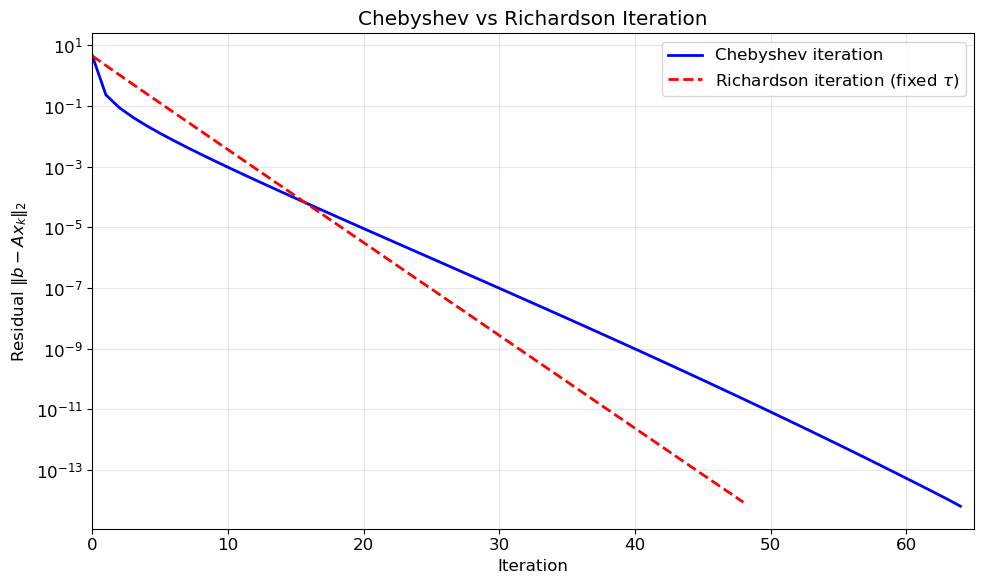

In [3]:
# Build a 20x20 tridiagonal SPD system
n = 20
A = np.diag([4.0] * n) + np.diag([1.0] * (n - 1), 1) + np.diag([1.0] * (n - 1), -1)
b = np.ones(n)

# Eigenvalue bounds (exact for tridiagonal: 4 + 2*cos(k*pi/(n+1)))
eigvals = np.sort(np.linalg.eigvalsh(A))
lmin, lmax = eigvals[0], eigvals[-1]
print(f"Eigenvalue range: [{lmin:.4f}, {lmax:.4f}], condition number: {lmax/lmin:.1f}")

# Solve with both methods
_, res_cheb = chebyshev_solve(A, b, lmin, lmax, max_iter=200, tol=1e-14, ordering="direct")
_, res_rich = richardson_solve(A, b, lmin, lmax, max_iter=200, tol=1e-14)

# Plot
fig, ax = plt.subplots()
ax.semilogy(res_cheb, 'b-', linewidth=2, label='Chebyshev iteration')
ax.semilogy(res_rich, 'r--', linewidth=2, label='Richardson iteration (fixed $\\tau$)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Residual $\\|b - Ax_k\\|_2$')
ax.set_title('Chebyshev vs Richardson Iteration')
ax.legend()
ax.set_xlim(0, max(len(res_cheb), len(res_rich)))
plt.tight_layout()
plt.show()

## 3. Parameter Ordering Comparison

The Chebyshev parameters can be applied in different orders. In exact arithmetic, all orderings produce the same result after a full cycle. In floating-point arithmetic, the ordering affects numerical stability.

- **Direct:** k = 1, 2, ..., n
- **Reverse:** k = n, n-1, ..., 1
- **Alternating:** k = 1, n, 2, n-1, ... (interleaves small and large parameters)

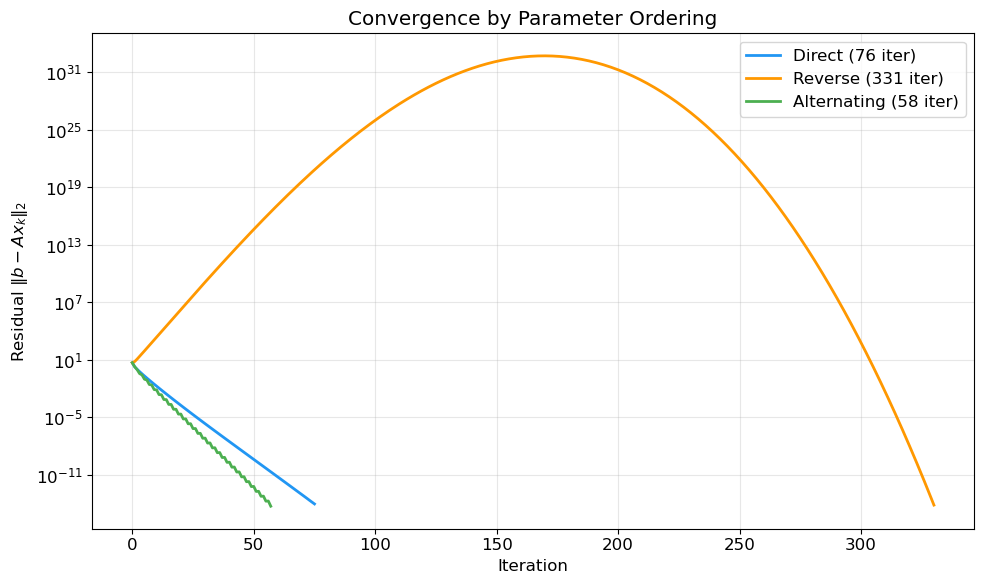

In [4]:
# Use a moderately conditioned system where ordering differences are visible
n = 30
A = np.diag([4.0] * n) + np.diag([1.0] * (n - 1), 1) + np.diag([1.0] * (n - 1), -1)
b = np.random.RandomState(42).randn(n)

eigvals = np.sort(np.linalg.eigvalsh(A))
lmin, lmax = eigvals[0], eigvals[-1]

orderings = {"Direct": "direct", "Reverse": "reverse", "Alternating": "alternating"}
colors = {"Direct": "#2196F3", "Reverse": "#FF9800", "Alternating": "#4CAF50"}

fig, ax = plt.subplots()
for name, ord_type in orderings.items():
    _, res = chebyshev_solve(A, b, lmin, lmax, max_iter=512, tol=1e-14, ordering=ord_type)
    ax.semilogy(res, linewidth=2, label=f'{name} ({len(res)} iter)', color=colors[name])

ax.set_xlabel('Iteration')
ax.set_ylabel('Residual $\\|b - Ax_k\\|_2$')
ax.set_title('Convergence by Parameter Ordering')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Effect of Eigenvalue Bound Tightness

The convergence rate depends on the ratio $\kappa = \lambda_{\max}/\lambda_{\min}$. Tighter bounds (closer to the true extreme eigenvalues) mean faster convergence. Here we show what happens when bounds are exact, 2x loose, and 5x loose.

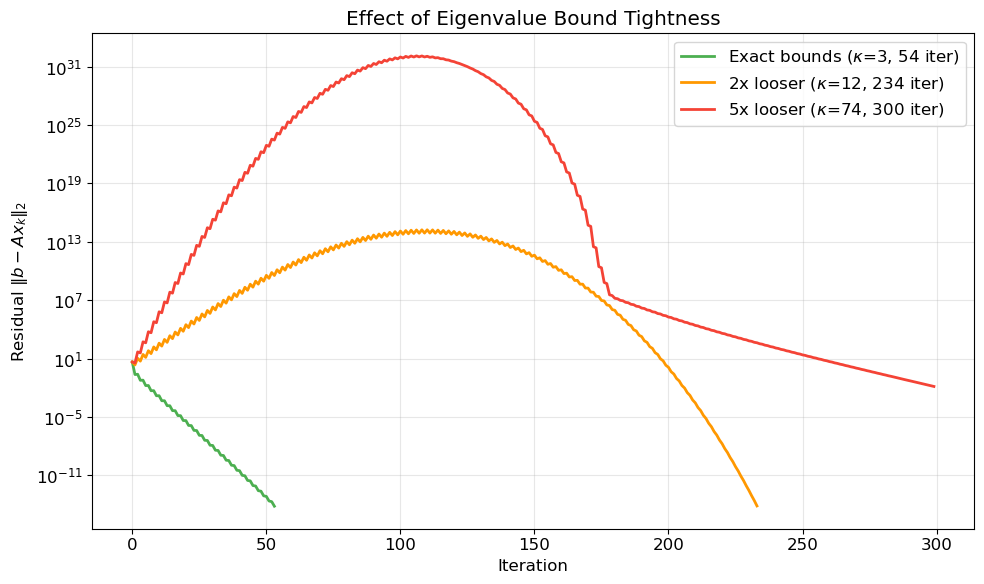

In [5]:
# Same system as section 2
n = 20
A = np.diag([4.0] * n) + np.diag([1.0] * (n - 1), 1) + np.diag([1.0] * (n - 1), -1)
b = np.ones(n)
eigvals = np.sort(np.linalg.eigvalsh(A))
lmin_exact, lmax_exact = eigvals[0], eigvals[-1]

bound_configs = [
    ("Exact bounds", lmin_exact, lmax_exact, "#4CAF50"),
    ("2x looser", lmin_exact / 2, lmax_exact * 2, "#FF9800"),
    ("5x looser", lmin_exact / 5, lmax_exact * 5, "#F44336"),
]

fig, ax = plt.subplots()
for label, lmin, lmax, color in bound_configs:
    kappa = lmax / lmin
    _, res = chebyshev_solve(A, b, lmin, lmax, max_iter=300, tol=1e-14, ordering="alternating")
    ax.semilogy(res, linewidth=2, label=f'{label} ($\\kappa$={kappa:.0f}, {len(res)} iter)', color=color)

ax.set_xlabel('Iteration')
ax.set_ylabel('Residual $\\|b - Ax_k\\|_2$')
ax.set_title('Effect of Eigenvalue Bound Tightness')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Chebyshev Polynomial Roots on the Eigenvalue Spectrum

The Chebyshev parameters $\tau_k = 1/d_k$ where $d_k$ are the roots of the Chebyshev polynomial $T_n$ shifted to $[\lambda_{\min}, \lambda_{\max}]$. These roots cluster near the endpoints, which is precisely what makes the method effective -- the error polynomial is minimized where eigenvalues are most likely to concentrate.

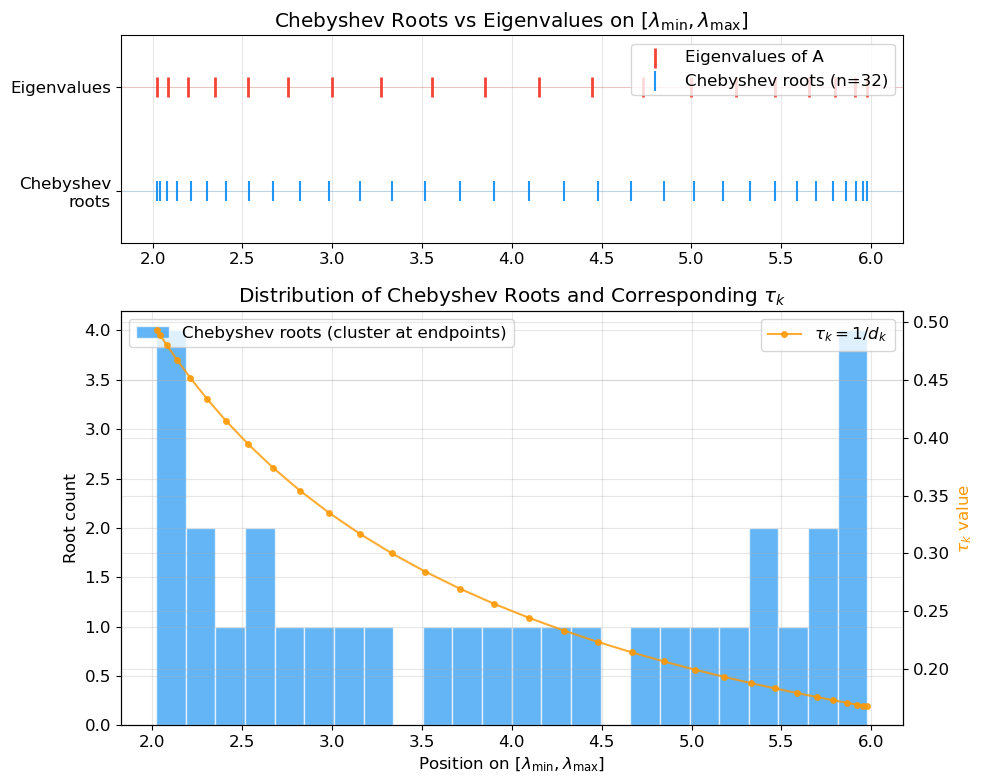

In [6]:
# Compute shifted Chebyshev roots and show them against the eigenvalue spectrum
n_poly = 32  # Chebyshev polynomial degree
n_mat = 20

A = np.diag([4.0] * n_mat) + np.diag([1.0] * (n_mat - 1), 1) + np.diag([1.0] * (n_mat - 1), -1)
eigvals = np.sort(np.linalg.eigvalsh(A))
lmin, lmax = eigvals[0], eigvals[-1]

# Shifted Chebyshev roots: d_k = (lmin+lmax)/2 + (lmax-lmin)/2 * cos(pi*(2k-1)/(2n))
ks = np.arange(1, n_poly + 1)
roots = (lmin + lmax) / 2 + (lmax - lmin) / 2 * np.cos(np.pi * (2 * ks - 1) / (2 * n_poly))
roots_sorted = np.sort(roots)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [1, 2]})

# Top: eigenvalues and Chebyshev roots on a number line
ax1 = axes[0]
ax1.scatter(eigvals, np.ones_like(eigvals), marker='|', s=200, c='#F44336', linewidths=2, label='Eigenvalues of A', zorder=3)
ax1.scatter(roots_sorted, np.zeros(len(roots_sorted)), marker='|', s=200, c='#2196F3', linewidths=1.5, label=f'Chebyshev roots (n={n_poly})', zorder=3)
ax1.axhline(1, color='#F44336', alpha=0.3, linewidth=0.5)
ax1.axhline(0, color='#2196F3', alpha=0.3, linewidth=0.5)
ax1.set_xlim(lmin - 0.2, lmax + 0.2)
ax1.set_ylim(-0.5, 1.5)
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Chebyshev\nroots', 'Eigenvalues'])
ax1.set_title(f'Chebyshev Roots vs Eigenvalues on $[\\lambda_{{\\min}}, \\lambda_{{\\max}}]$')
ax1.legend(loc='upper right')

# Bottom: histogram of Chebyshev root density vs uniform spacing
ax2 = axes[1]
bins = np.linspace(lmin, lmax, 25)
ax2.hist(roots_sorted, bins=bins, alpha=0.7, color='#2196F3', edgecolor='white', label='Chebyshev roots (cluster at endpoints)')

# Show the tau values
taus = 1.0 / roots_sorted
ax2_twin = ax2.twinx()
ax2_twin.plot(roots_sorted, taus, 'o-', color='#FF9800', markersize=4, alpha=0.8, label='$\\tau_k = 1/d_k$')
ax2_twin.set_ylabel('$\\tau_k$ value', color='#FF9800')

ax2.set_xlabel('Position on $[\\lambda_{\\min}, \\lambda_{\\max}]$')
ax2.set_ylabel('Root count')
ax2.set_title('Distribution of Chebyshev Roots and Corresponding $\\tau_k$')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 6. The Error Polynomial

The Chebyshev iteration minimizes the maximum of the error polynomial $p_n(\lambda)$ over $[\lambda_{\min}, \lambda_{\max}]$, where $p_n(\lambda) = \prod_{k=1}^{n}(1 - \tau_k \lambda)$. This is exactly the [minimax property](https://en.wikipedia.org/wiki/Chebyshev_polynomials#Properties) of Chebyshev polynomials -- no other degree-n polynomial with $p_n(0) = 1$ has a smaller maximum on the interval.

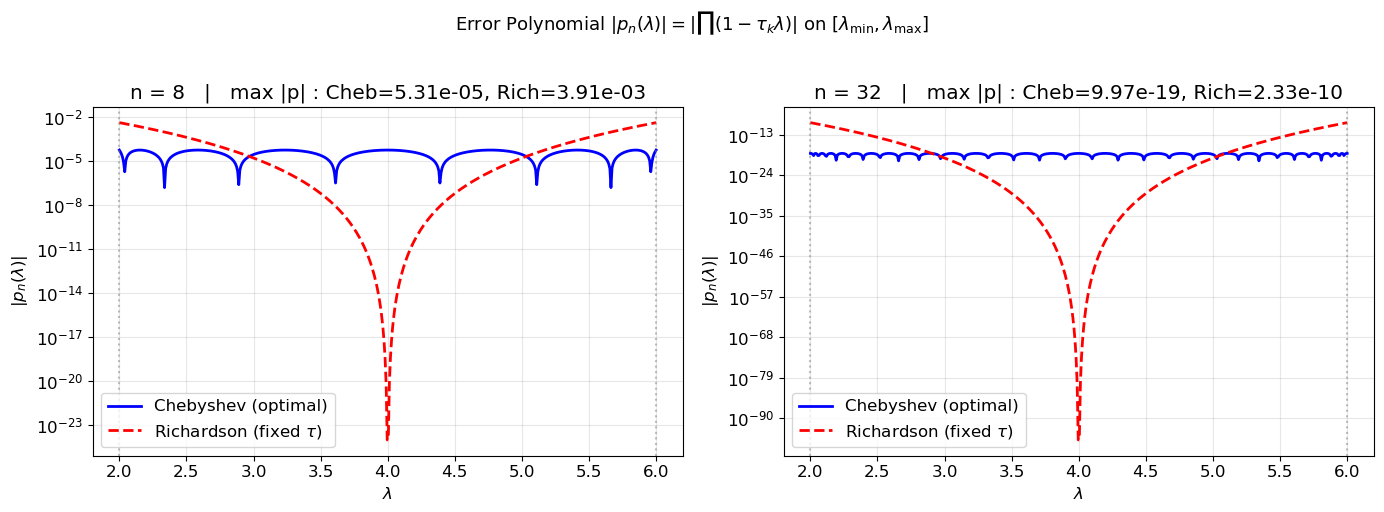

In [7]:
# Compare the error polynomial for Chebyshev vs Richardson (fixed tau)
lmin, lmax = 2.0, 6.0
lambdas = np.linspace(lmin, lmax, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, n_poly in enumerate([8, 32]):
    ax = axes[idx]
    
    # Chebyshev error polynomial: product of (1 - tau_k * lambda)
    taus_cheb = [tau(k, n_poly, lmin, lmax) for k in range(1, n_poly + 1)]
    p_cheb = np.ones_like(lambdas)
    for tk in taus_cheb:
        p_cheb *= (1 - tk * lambdas)
    
    # Richardson error polynomial: (1 - tau_fixed * lambda)^n
    tau_rich = 2.0 / (lmin + lmax)
    p_rich = (1 - tau_rich * lambdas) ** n_poly
    
    ax.plot(lambdas, np.abs(p_cheb), 'b-', linewidth=2, label='Chebyshev (optimal)')
    ax.plot(lambdas, np.abs(p_rich), 'r--', linewidth=2, label='Richardson (fixed $\\tau$)')
    ax.axvline(lmin, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(lmax, color='gray', linestyle=':', alpha=0.5)
    
    max_cheb = np.max(np.abs(p_cheb))
    max_rich = np.max(np.abs(p_rich))
    ax.set_title(f'n = {n_poly}   |   max |p| : Cheb={max_cheb:.2e}, Rich={max_rich:.2e}')
    ax.set_xlabel('$\\lambda$')
    ax.set_ylabel('$|p_n(\\lambda)|$')
    ax.set_yscale('log')
    ax.legend()

plt.suptitle('Error Polynomial $|p_n(\\lambda)| = |\\prod(1 - \\tau_k \\lambda)|$ on $[\\lambda_{\\min}, \\lambda_{\\max}]$', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Convergence Rate vs Condition Number

The theoretical convergence factor per iteration is $\rho = \frac{1 - \sqrt{\xi}}{1 + \sqrt{\xi}}$ where $\xi = \lambda_{\min}/\lambda_{\max}$. As the condition number grows, convergence slows dramatically.

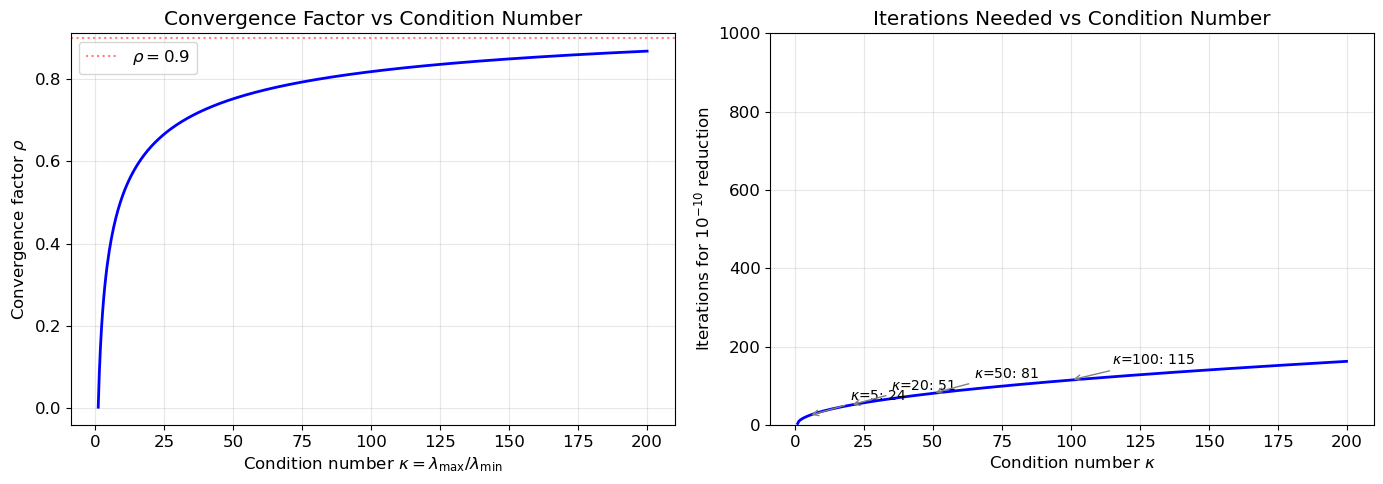

In [8]:
# Theoretical convergence factor vs condition number
kappas = np.linspace(1.01, 200, 500)
xi = 1.0 / kappas
rho = (1 - np.sqrt(xi)) / (1 + np.sqrt(xi))

# Iterations needed to reduce error by factor of 1e-10
iters_needed = np.log(1e-10) / np.log(rho)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(kappas, rho, 'b-', linewidth=2)
ax1.set_xlabel('Condition number $\\kappa = \\lambda_{\\max}/\\lambda_{\\min}$')
ax1.set_ylabel('Convergence factor $\\rho$')
ax1.set_title('Convergence Factor vs Condition Number')
ax1.axhline(0.9, color='r', linestyle=':', alpha=0.5, label='$\\rho = 0.9$')
ax1.legend()

ax2 = axes[1]
ax2.plot(kappas, iters_needed, 'b-', linewidth=2)
ax2.set_xlabel('Condition number $\\kappa$')
ax2.set_ylabel('Iterations for $10^{-10}$ reduction')
ax2.set_title('Iterations Needed vs Condition Number')
ax2.set_ylim(0, 1000)

# Mark a few notable points
for kappa_mark in [5, 20, 50, 100]:
    xi_m = 1.0 / kappa_mark
    rho_m = (1 - np.sqrt(xi_m)) / (1 + np.sqrt(xi_m))
    iters_m = np.log(1e-10) / np.log(rho_m)
    ax2.annotate(f'$\\kappa$={kappa_mark}: {iters_m:.0f}',
                 xy=(kappa_mark, iters_m), fontsize=10,
                 xytext=(kappa_mark + 15, iters_m + 40),
                 arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

---

## Summary

| Visualization | Key Insight |
|---|---|
| Chebyshev vs Richardson | Chebyshev parameters accelerate convergence by orders of magnitude |
| Ordering comparison | Alternating ordering is most numerically stable |
| Eigenvalue bound tightness | Loose bounds still converge, but much slower |
| Chebyshev roots | Roots cluster at endpoints of the eigenvalue interval |
| Error polynomial | Chebyshev achieves the minimax-optimal error polynomial |
| Condition number | Iterations scale as $O(\sqrt{\kappa})$, practical for $\kappa < 100$ |

For production use in Go, see the [chebyshev-iteration library](https://github.com/peterborodatyy/chebyshev-iteration).